# Feature Engineering and Polynomial Regression

In this notebook we will learn:

- What feature engineering is
- How polynomial features help linear regression
- Why feature scaling is important

We will use **NumPy for calculations** and **Matplotlib for graphs**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Create Dataset

We create a simple dataset.

- `x` contains numbers from 0 to 19.
- `y = 1 + x²`

This means the relationship between **x and y is curved**, not a straight line.

In [2]:
x = np.arange(0, 20, 1)
y = 1 + x**2

print("x values:", x)
print("y values:", y)

x values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
y values: [  1   2   5  10  17  26  37  50  65  82 101 122 145 170 197 226 257 290
 325 362]


## Step 3: Visualize the Data

Now we plot the dataset.

Since the equation is **y = 1 + x²**, the graph will form a **curve**.

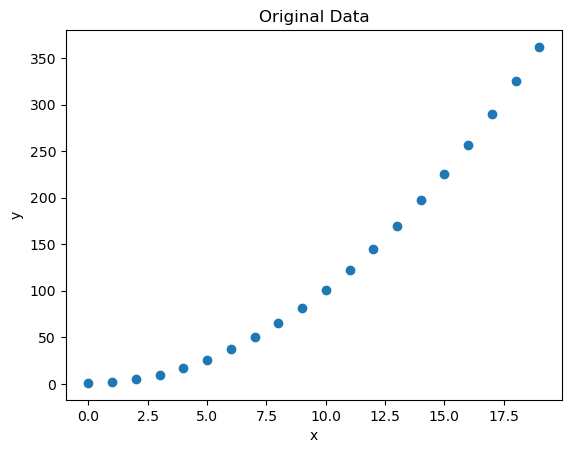

In [3]:
plt.scatter(x, y)
plt.title("Original Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Step 4: Prepare Data for Linear Regression

Machine learning models expect **input features in matrix form**.

`reshape(-1,1)` converts the vector into a **2D matrix**.

In [4]:
X = x.reshape(-1,1)
print(X[:5])

[[0]
 [1]
 [2]
 [3]
 [4]]


## Step 5: Train a Simple Linear Regression Model

We implement a very simple **gradient descent algorithm**.

Variables:

- `w` → weight
- `b` → bias
- `alpha` → learning rate
- `iterations` → number of training steps

The model tries to minimize prediction error.

In [5]:
w = 0
b = 0

alpha = 0.0001
iterations = 1000

m = len(x)

for i in range(iterations):

    y_pred = w * X[:,0] + b

    dw = (1/m) * np.sum((y_pred - y) * X[:,0])
    db = (1/m) * np.sum(y_pred - y)

    w = w - alpha * dw
    b = b - alpha * db

print("Weight:", w)
print("Bias:", b)

Weight: 14.712456889583942
Bias: -0.38344163122477315


## Step 6: Plot Model Predictions

We compare:

- **Actual values** (dataset)
- **Predicted values** (model output)

Because linear regression fits a straight line, it will not fit the curve well.

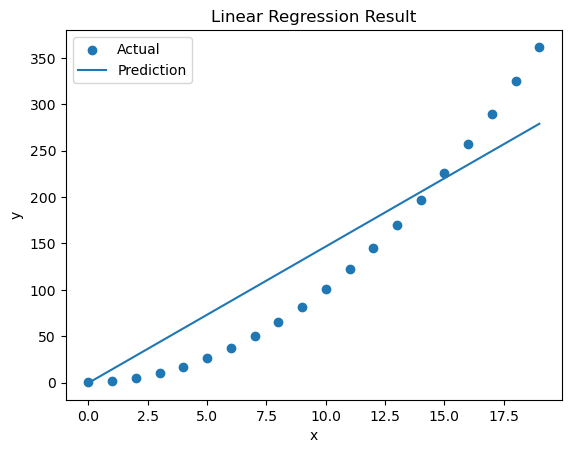

In [6]:
y_pred = w * X[:,0] + b

plt.scatter(x, y, label="Actual")
plt.plot(x, y_pred, label="Prediction")
plt.title("Linear Regression Result")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Step 7: Feature Engineering

Feature engineering means **creating new features from existing data**.

Here we create a new feature:

x²

This allows the model to capture the curved relationship.

In [7]:
X = x**2
X = X.reshape(-1,1)

print(X[:5])

[[ 0]
 [ 1]
 [ 4]
 [ 9]
 [16]]


## Step 8: Train Model Again Using Polynomial Feature

Now we train the model again using **x² instead of x**.

This allows the model to learn the correct curve.

In [8]:
w = 0
b = 0

alpha = 0.0000001
iterations = 10000

m = len(x)

for i in range(iterations):

    y_pred = w * X[:,0] + b

    dw = (1/m) * np.sum((y_pred - y) * X[:,0])
    db = (1/m) * np.sum(y_pred - y)

    w = w - alpha * dw
    b = b - alpha * db

print("Weight:", w)
print("Bias:", b)

Weight: 1.0043685311505124
Bias: 0.004864799143698324


## Step 9: Plot New Predictions

Now the model should fit the curve much better.

Because we added **x²**, the model can represent a polynomial function.

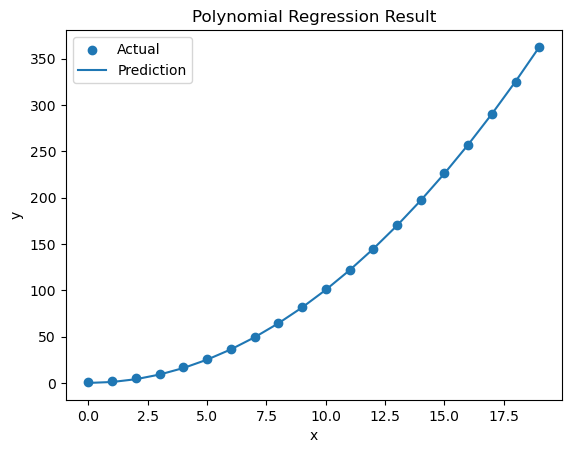

In [9]:
y_pred = w * X[:,0] + b

plt.scatter(x, y, label="Actual")
plt.plot(x, y_pred, label="Prediction")
plt.title("Polynomial Regression Result")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Step 10: Multiple Polynomial Features

Sometimes we add multiple features such as:

- x
- x²
- x³

The model will automatically learn which feature is most important.

In [10]:

X = np.c_[x, x**2, x**3]

print(X[:5])

[[ 0  0  0]
 [ 1  1  1]
 [ 2  4  8]
 [ 3  9 27]
 [ 4 16 64]]


## Step 11: Feature Scaling

Features like **x, x², x³** have very different ranges.

Feature scaling helps gradient descent **converge faster**.

We use **Z-score normalization**:

X = (X - mean) / standard deviation

In [11]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_norm = (X - mean) / std

print(X_norm[:5])

[[-1.64750894 -1.08815641 -0.86396619]
 [-1.47408695 -1.07934543 -0.86348754]
 [-1.30066495 -1.05291248 -0.86013698]
 [-1.12724296 -1.00885756 -0.8510426 ]
 [-0.95382097 -0.94718068 -0.83333249]]


## Conclusion

In this lab we learned:

- Linear regression normally fits straight lines.
- Real world data is often non-linear.
- Feature engineering creates useful new features.
- Polynomial features like x² help fit curves.
- Feature scaling improves training speed.